In [1]:
from utils.utils import DataLoader, DopplerDataset, plot_learning_curves
from networks.model import Network_Class
import numpy as np
import matplotlib.pyplot as plt
import yaml
import os

# Load Data
base_path = "/Volumes/HIP_BACKUP/MEMOIRE/Code/MyDB2"
all = [f"NewExp{i}" for i in range(1, 51)]


In [2]:
l_exp = [f"Regression/BET_Reg_4"] # Regression/Reg_1

data_loader = DataLoader(base_path, exp_list=all)

for exp in l_exp :
    #exp = "DefaultExp"
    print(f"🔔 Starting {exp}")
    stream = open(f"exp_list/{exp}.yaml", 'r')
    param  = yaml.safe_load(stream)
    param["TRAINING"]["DEVICE"] = 'mps'

    resultsPath = os.path.join("results", exp)

    # Create the directory
    if not os.path.exists(resultsPath):
        os.makedirs(resultsPath)

    myNetwork = Network_Class(data_loader, param, resultsPath, sub_sample_factor=1)

    # Train the network
    train_losses, val_losses =  myNetwork.train()

    # Test the network
    #myNetwork.loadWeight()
    #myNetwork.test()   





🔄 Chargement des données:   0%|          | 0/50 [00:00<?, ?exp/s]

🔄 Chargement des données: 100%|██████████| 50/50 [00:01<00:00, 31.01exp/s]


🔔 Starting Regression/BET_Reg_4
✅ Network Initialized


🟢 Epoch 1/15:   0%|          | 4/2478 [00:09<1:37:35,  2.37s/batch, loss=0.9590]


KeyboardInterrupt: 

In [3]:
print(len(myNetwork.dataSetTrain))
print(len(myNetwork.dataSetTest))
print(len(myNetwork.dataSetVal))

39640
4955
4955


In [ ]:
num_params = sum(p.numel() for p in myNetwork.model.parameters())
print(f"Number of parameters: {num_params}") 
# V1 = 2.147.874.498
# V2 = 8.482.754
# V3 = 2.190.530
# V_reg = 2.190.465
# V_reg_48CH = 12.833.441

Number of parameters: 12833441


[0.23496415161415934, 0.1496273690342903, 0.12940428604707122, 0.11690187167152763, 0.10765617779940367, 0.10118418045155704, 0.09485008568987251, 0.08798057694807648, 0.0836830946907401, 0.07802168282046915, 0.07398077975604683, 0.069784684375301, 0.06702993894554675, 0.06314343673884869, 0.059334752087667586]
[0.15753570399284364, 0.1519801495075226, 0.19170800808668137, 0.19976791036129, 0.17247786046266556, 0.19020338563919068, 0.20856560215950012, 0.20016228059530258, 0.17882753208875657, 0.18345146530866624, 0.20029571447372438, 0.18396198621988297, 0.1758973748445511, 0.1687733619570732, 0.15267085871696473]


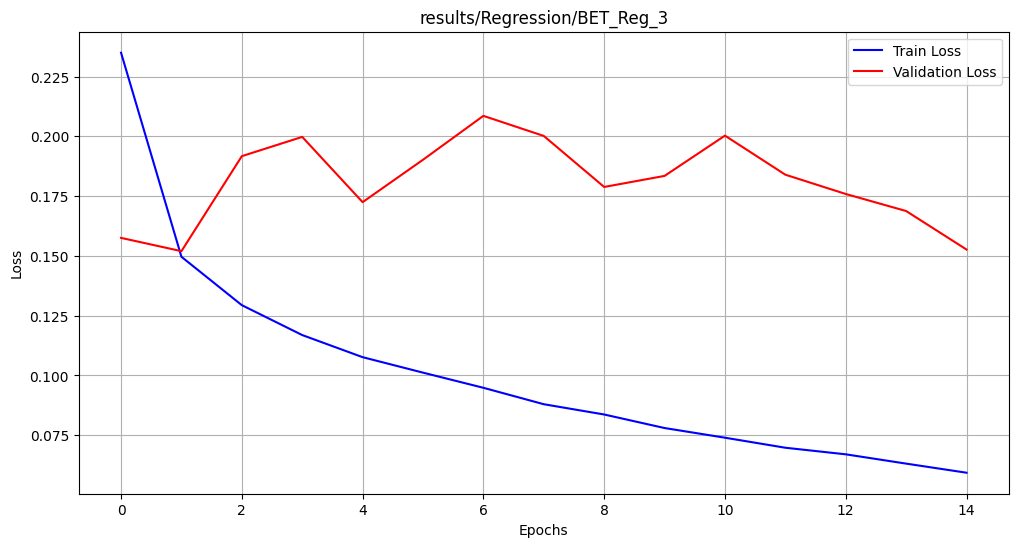

In [3]:
# Load learning curves
#train_losses = np.load(os.path.join(resultsPath, "train_losses.npy"))
#val_losses = np.load(os.path.join(resultsPath, "val_losses.npy"))
print(train_losses)
print(val_losses)
plot_learning_curves(train_losses, val_losses, resultsPath)